In [1]:
# 1. Portfolio Setup
# 2. Simulation Framework
# 3. VaR & Expected Shortfall
# 4. Backtesting
# 5. Stress Testing
# 6. Sensitivity Analysis
# 7. Key Insights

### Market Risk Engine Demo

This notebook demonstrates a modular quantitative risk framework including:

- Monte Carlo Value-at-Risk (VaR)
- Expected Shortfall (ES)
- Backtesting (Violation Analysis)
- Stress Testing
- Sensitivity Analysis

The implementation uses correlated asset return simulations and replicates workflows used in financial risk management.

In [6]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from src.simulation import simulate_multivariate_returns
from src.var import compute_var, compute_es

In [8]:
# Portfolio weights
weights = np.array([0.4, 0.3, 0.3])

# Expected returns (daily)
mu = np.array([0.0005, 0.0003, 0.0004])

# Covariance matrix
cov = np.array([
    [0.0001, 0.00002, 0.000015],
    [0.00002, 0.00008, 0.00001],
    [0.000015, 0.00001, 0.00009]
])

n_sims = 10000

In [9]:
# Generate correlated asset returns
simulated_returns = simulate_multivariate_returns(mu, cov, n_sims)

# Portfolio returns
portfolio_returns = simulated_returns @ weights

In [10]:
alpha_95 = 0.95
alpha_99 = 0.99

var_95 = compute_var(portfolio_returns, alpha_95)
var_99 = compute_var(portfolio_returns, alpha_99)

es_95 = compute_es(portfolio_returns, alpha_95)
es_99 = compute_es(portfolio_returns, alpha_99)

print("==== Risk Metrics ====")
print(f"VaR 95%: {var_95:.6f}")
print(f"VaR 99%: {var_99:.6f}")
print(f"ES 95%: {es_95:.6f}")
print(f"ES 99%: {es_99:.6f}")

==== Risk Metrics ====
VaR 95%: -0.010386
VaR 99%: -0.014882
ES 95%: -0.013143
ES 99%: -0.017230


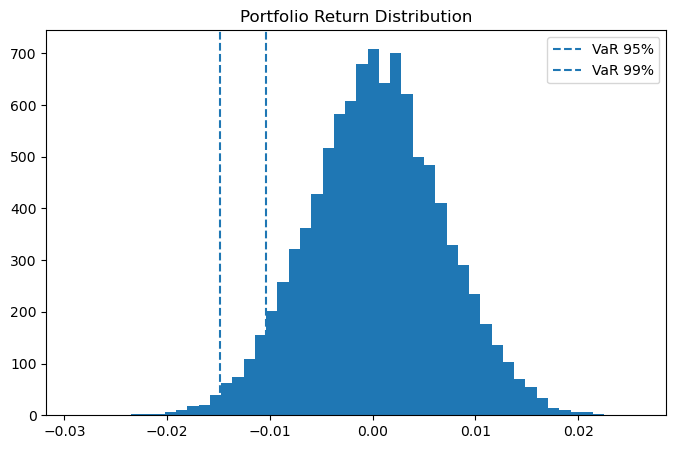

In [11]:
plt.figure(figsize=(8,5))
plt.hist(portfolio_returns, bins=50)

plt.axvline(var_95, linestyle='--', label='VaR 95%')
plt.axvline(var_99, linestyle='--', label='VaR 99%')

plt.title("Portfolio Return Distribution")
plt.legend()
plt.show()

In [12]:
# Simulated "historical" data
historical_returns = simulate_multivariate_returns(mu, cov, 250)
portfolio_hist = historical_returns @ weights

violations = np.sum(portfolio_hist < var_95)

print("==== Backtesting ====")
print(f"VaR breaches (95%): {violations} out of 250")

==== Backtesting ====
VaR breaches (95%): 12 out of 250


In [13]:
# Define stress shock
shock = np.array([-0.05, -0.04, -0.06])

stressed_returns = mu + shock
stressed_portfolio = stressed_returns @ weights

print("==== Stress Testing ====")
print(f"Stressed Portfolio Return: {stressed_portfolio:.6f}")

==== Stress Testing ====
Stressed Portfolio Return: -0.049590


In [14]:
# Increase volatility
cov_stressed = cov * 1.5

sim_stressed = simulate_multivariate_returns(mu, cov_stressed, n_sims)
portfolio_stressed = sim_stressed @ weights

var_stressed = compute_var(portfolio_stressed, alpha_95)

print("==== Sensitivity Analysis ====")
print(f"Original VaR (95%): {var_95:.6f}")
print(f"Stressed VaR (95%): {var_stressed:.6f}")

==== Sensitivity Analysis ====
Original VaR (95%): -0.010386
Stressed VaR (95%): -0.012510


## Key Insights

- Expected Shortfall exceeds VaR, capturing extreme tail losses beyond the VaR threshold.
- VaR increases under higher volatility, demonstrating sensitivity to market uncertainty.
- Backtesting violations help assess whether the model underestimates risk.
- Stress testing highlights portfolio vulnerability under extreme but plausible shocks.
- Correlation assumptions significantly impact aggregated portfolio risk.

In [16]:
Hi!

SyntaxError: invalid syntax (4274222715.py, line 1)